## Indlæser masterdatasættet

In [3]:
import pandas as pd
import numpy as np
import os

BASE = "/Users/PC/Documents/Speciale/Analyse/Speciale"
CLEAN_DIR = os.path.join(BASE, "clean")

master = pd.read_csv(os.path.join(CLEAN_DIR, "master_monthly.csv"))
master["month"] = pd.to_datetime(master["month"])

### TPU, GPR, GPR_USA, VIX - log, standardisering + persistens tjek

In [4]:
import statsmodels.formula.api as smf

# Log + standardisering (bruges som regressor i LP: lnTPU_z osv.)
for v in ["TPU", "GPR", "GPRC_USA", "VIXCLS"]:
    master[f"ln{v}"] = np.log(master[v])
    master[f"ln{v}_z"] = (master[f"ln{v}"] - master[f"ln{v}"].mean()) / master[f"ln{v}"].std()

# phi-tjek (deskriptivt - dokumenterer persistensen i teksten)
for v in ["TPU", "GPR", "GPRC_USA"]:
    tmp = master.assign(lag=master[f"ln{v}"].shift(1)).dropna(subset=[f"ln{v}","lag"])
    phi = smf.ols(f"ln{v} ~ lag", data=tmp).fit().params["lag"]
    grad = "stærkt persistent (nær enhedsrod)" if phi > 0.85 else "moderat persistent"
    print(f"{v}: phi = {phi:.3f}   ({grad})")


TPU: phi = 0.916   (stærkt persistent (nær enhedsrod))
GPR: phi = 0.728   (moderat persistent)
GPRC_USA: phi = 0.712   (moderat persistent)


#### Kontroller

In [5]:
# Real aktivitet: log-difference (vækst) - kontroller
master["ip_growth"]  = np.log(master["INDPRO"]).diff()
master["nfp_growth"] = np.log(master["PAYEMS"]).diff()

# Renter: første-difference - kontroller
master["d_DGS10"]  = master["DGS10"].diff()
master["d_us_rf"]  = master["us_rf"].diff()

### USD Hedge ratio figur

       month  USD_hedge_ratio         hr
0 2015-01-31         0.761942  76.194212
1 2015-02-28         0.732988  73.298796
2 2015-03-31         0.754138  75.413771
count    139.000000
mean      72.223943
std        5.397473
min       60.621828
25%       67.831094
50%       72.218490
75%       76.081654
max       82.117073
Name: hr, dtype: float64


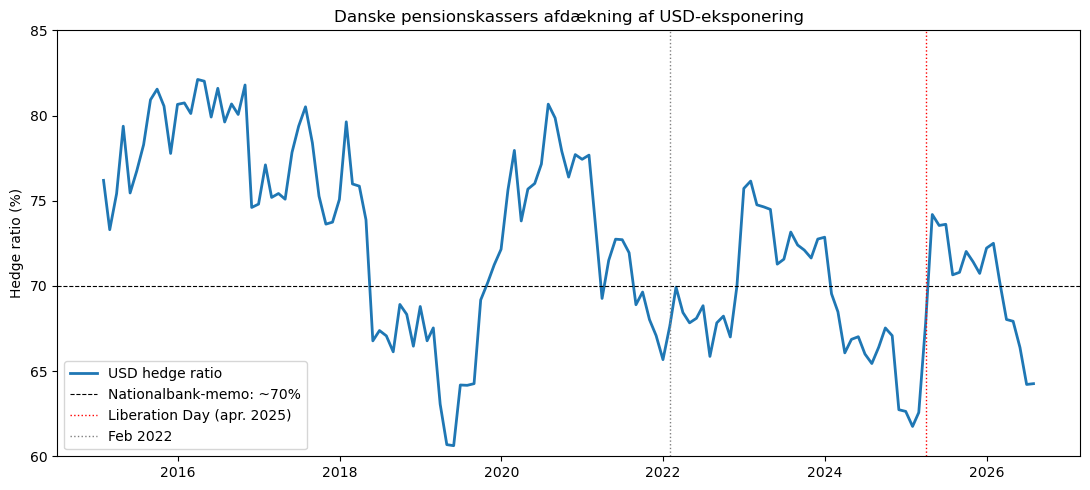

Min: 60.6%  Max: 82.1%
Jan 2025: [61.75150912] -> Apr 2025: [74.18902791]
Afdækket USD-eksponering: start (2015-01-31) = 495.3   slut (2026-07-31) = 1231.3
Uafdækket USD-eksponering: start (2015-01-31) = 154.7   slut (2026-07-31) = 684.8
Hedge ratio (%): start (2015-01-31) = 76.2   slut (2026-07-31) = 64.3


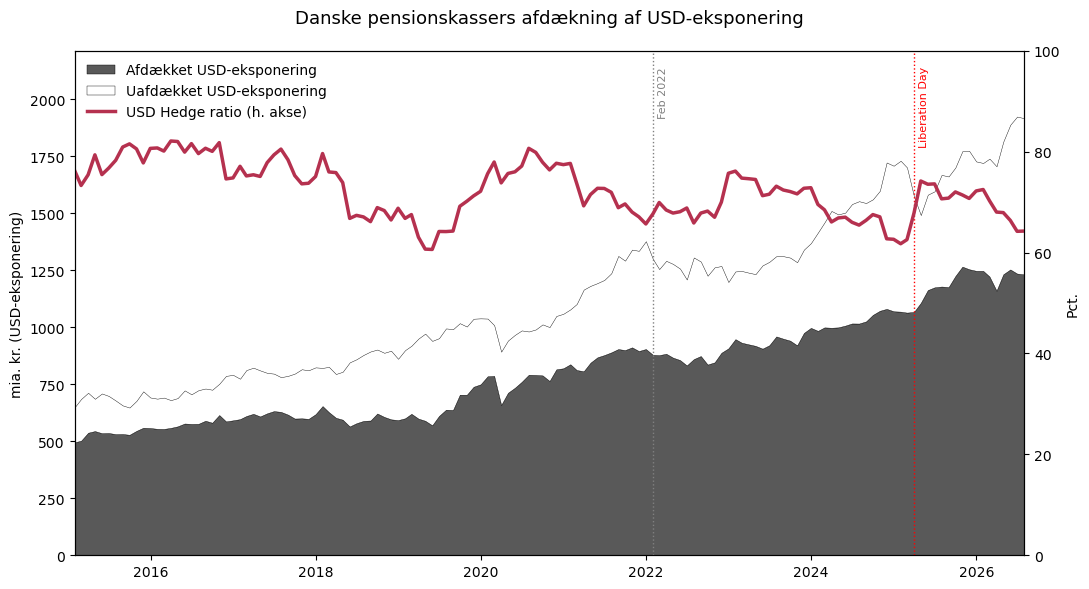

In [6]:
import matplotlib.pyplot as plt

# ============================================================
# USD hedge ratio — er afdækningsgraden tidsvarierende?
# ============================================================
d = master.dropna(subset=["USD_hedge_ratio"]).copy()
d["hr"] = d["USD_hedge_ratio"] * 100

# tjek
print(d[["month","USD_hedge_ratio","hr"]].head(3))
print(d["hr"].describe())

fig, ax = plt.subplots(figsize=(11,5))
ax.plot(d["month"], d["hr"], lw=2, color="tab:blue", label="USD hedge ratio")
ax.set_ylim(60, 85)   # (min, max) i procent — juster tallene til det, der passer til din data
ax.axhline(70, color="black", lw=0.8, ls="--", label="Nationalbank-memo: ~70%")
ax.axvline(pd.Timestamp("2025-04-01"), color="red", lw=1, ls=":", label="Liberation Day (apr. 2025)")
ax.axvline(pd.Timestamp("2022-02-01"), color="gray", lw=1, ls=":", label="Feb 2022")

ax.set_title("Danske pensionskassers afdækning af USD-eksponering")
ax.set_ylabel("Hedge ratio (%)")
ax.legend()
plt.tight_layout()
plt.show()

# nøgletal til vejledermødet
apr25 = d.loc[d["month"] == "2025-04-30", "hr"].values
jan25 = d.loc[d["month"] == "2025-01-31", "hr"].values
print(f"Min: {d['hr'].min():.1f}%  Max: {d['hr'].max():.1f}%")
print(f"Jan 2025: {jan25} -> Apr 2025: {apr25}")

# ============================================================
# USD-eksponering: afdækket vs. uafdækket, med hedge ratio
# Efterligner Nationalbankens figur (stablet areal + linje på højre akse)
# ============================================================
d = master.dropna(subset=["USD_hedge_ratio","USD_afd_total","USD_uafd_total","USD_eksp_total"]).copy()
d["hr"] = d["USD_hedge_ratio"] * 100

fig, ax1 = plt.subplots(figsize=(11,6))

for col, navn in [("USD_afd_total", "Afdækket USD-eksponering"),
                   ("USD_uafd_total", "Uafdækket USD-eksponering"),
                   ("hr", "Hedge ratio (%)")]:
    start = d[col].iloc[0]
    slut = d[col].iloc[-1]
    print(f"{navn}: start ({d['month'].iloc[0].date()}) = {start:.1f}   "
          f"slut ({d['month'].iloc[-1].date()}) = {slut:.1f}")

# Stablet areal: afdækket (mørkegrå) nederst, uafdækket (hvid) ovenpå
ax1.stackplot(
    d["month"],
    d["USD_afd_total"], d["USD_uafd_total"],
    labels=["Afdækket USD-eksponering", "Uafdækket USD-eksponering"],
    colors=["#595959", "white"],
    edgecolor="black", linewidth=0.3,
)
ax1.set_ylabel("mia. kr. (USD-eksponering)")
ax1.set_ylim(0, d["USD_eksp_total"].max() * 1.15)
ax1.set_xlim(pd.Timestamp("2015-01-31"), pd.Timestamp("2026-07-31"))

# Hedge ratio på højre akse
ax2 = ax1.twinx()
ax2.plot(d["month"], d["hr"], color="#b5314f", lw=2.5, label="USD Hedge ratio (h. akse)")
ax2.set_ylabel("Pct.")
ax2.set_ylim(0, 100)  # juster til dataens variation

# Marker Liberation Day
offset = pd.Timedelta(days=20)

ax1.axvline(pd.Timestamp("2025-04-01"), color="red", lw=1, ls=":")
ax1.text(pd.Timestamp("2025-04-01") + offset, ax1.get_ylim()[1]*0.97, "Liberation Day",
         color="red", fontsize=8, rotation=90, va="top", ha="left")

ax1.axvline(pd.Timestamp("2022-02-01"), color="gray", lw=1, ls=":")
ax1.text(pd.Timestamp("2022-02-01") + offset, ax1.get_ylim()[1]*0.97, "Feb 2022",
         color="gray", fontsize=8, rotation=90, va="top", ha="left")

ax1.set_title("Danske pensionskassers afdækning af USD-eksponering", fontsize=13, loc="center", pad=20)
# Fælles legend for begge akser
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

# LP-Projections - TPU, GPR, GPR_USA


=== TPU ===
 h  coef    se     t     p   sig
 0 0.451 0.516 0.874 0.382      
 1 0.887 0.984 0.901 0.368      
 2 0.131 1.167 0.112 0.911      
 3 0.007 1.000 0.007 0.994      
 4 0.310 0.942 0.329 0.742      
 5 0.672 1.163 0.578 0.563      
 6 1.570 0.981 1.601 0.109 (68%)
 7 2.020 0.914 2.210 0.027    **
 8 1.745 1.157 1.508 0.131 (68%)
 9 1.948 1.130 1.724 0.085     *
10 1.153 1.113 1.036 0.300 (68%)
11 1.418 1.099 1.290 0.197 (68%)
12 1.674 1.059 1.581 0.114 (68%)
13 1.808 1.368 1.322 0.186 (68%)
14 2.070 1.290 1.604 0.109 (68%)
15 2.063 1.319 1.564 0.118 (68%)
16 2.036 1.261 1.615 0.106 (68%)
17 2.802 1.427 1.963 0.050    **
18 2.371 1.824 1.300 0.194 (68%)

=== GPR (globalt) ===
 h   coef    se      t     p   sig
 0 -0.003 0.173 -0.015 0.988      
 1  0.426 0.343  1.244 0.214 (68%)
 2 -0.073 0.319 -0.228 0.819      
 3 -0.174 0.413 -0.421 0.674      
 4 -0.041 0.402 -0.101 0.919      
 5  0.296 0.514  0.577 0.564      
 6  0.718 0.474  1.516 0.130 (68%)
 7  0.722 0.560  1.291 0

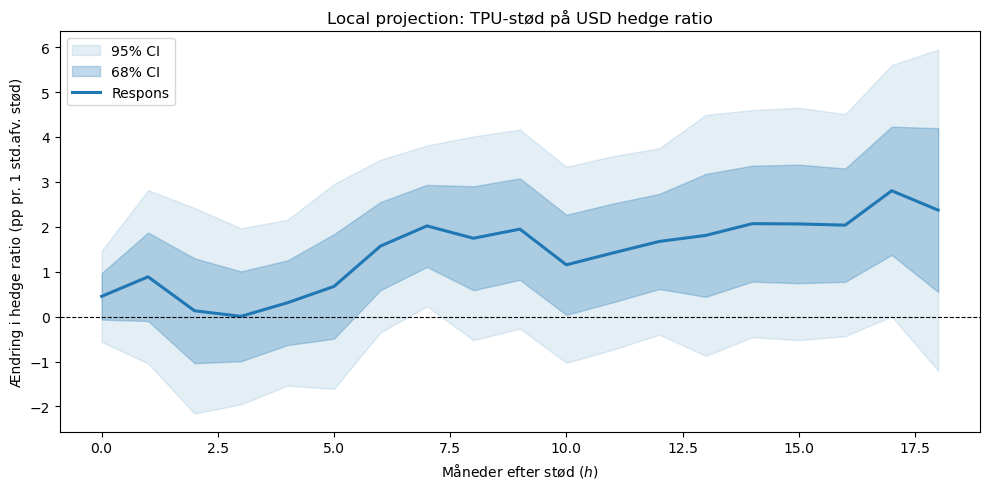

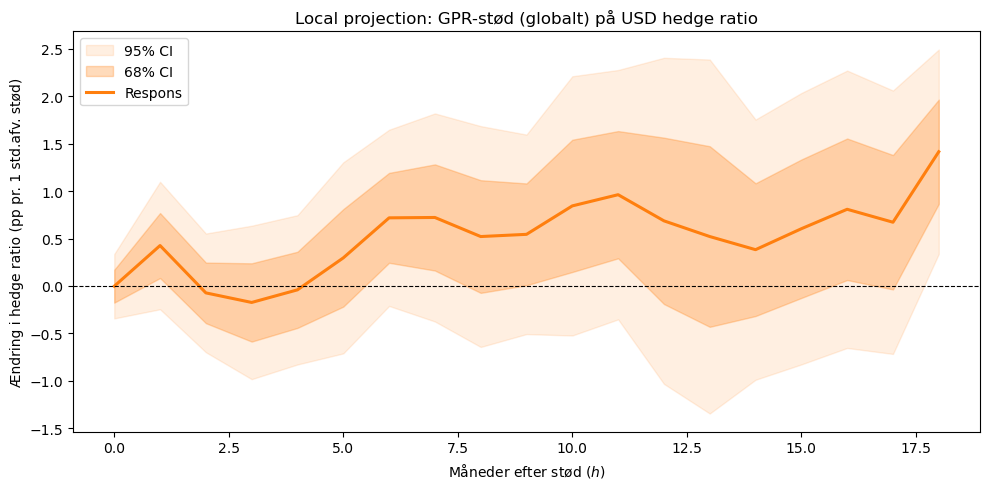

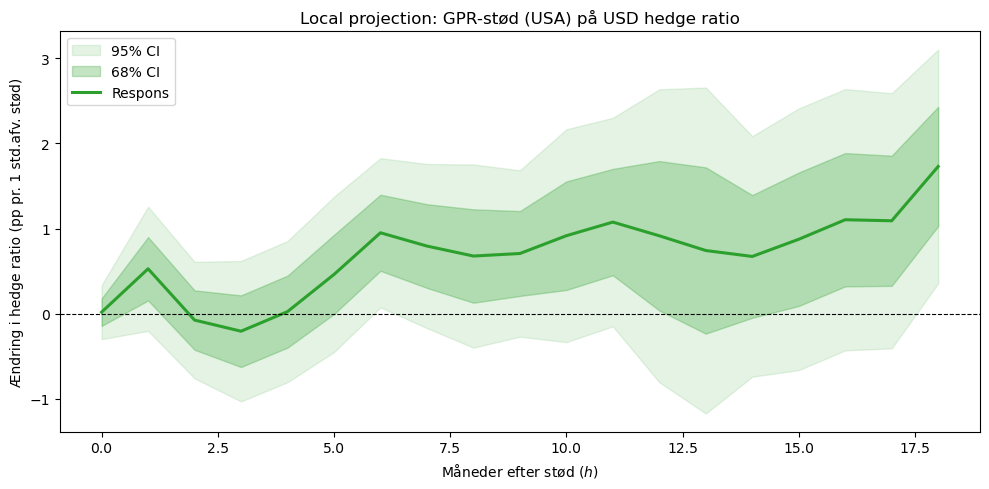

In [7]:
from scipy import stats

def lp_lagaug(master, indeks, H=18, LP_LAGS=2, NW_LAG=18):
    """Lag-augmenteret LP: effekt af et usikkerhedsstød på USD hedge ratio.
    'indeks' er navnet på det log-standardiserede indeks, fx 'lnTPU_z'."""
    d = master.copy().sort_values("month").reset_index(drop=True)
    d["hr"] = d["USD_hedge_ratio"] * 100

    # Lag-augmentation: den foregående måneds værdi af regressoren som kontrol
    d[f"{indeks}_lag1"] = d[indeks].shift(1)

    # Stationære kontroller (laggede), jf. Jordà
    kontroller = ["ip_growth", "inflation", "d_DGS10"]
    lag_termer = [f"{indeks}_lag1"]
    for var in kontroller:
        for L in range(1, LP_LAGS + 1):
            d[f"{var}_l{L}"] = d[var].shift(L)
            lag_termer.append(f"{var}_l{L}")
    kontrol_formel = " + ".join(lag_termer)

    res = []
    for h in range(H + 1):
        d[f"hr_lead{h}"] = d["hr"].shift(-h) - d["hr"].shift(1)   # long difference
        sub = d.dropna(subset=[f"hr_lead{h}", indeks] + lag_termer)
        m = smf.ols(f"hr_lead{h} ~ {indeks} + {kontrol_formel}",
                    data=sub).fit(cov_type="HAC", cov_kwds={"maxlags": NW_LAG})
        res.append({"h": h, "coef": m.params[indeks],
                    "se": m.bse[indeks], "n": int(m.nobs)})

    lp = pd.DataFrame(res)
    lp["ci68_low"], lp["ci68_high"] = lp["coef"]-lp["se"],      lp["coef"]+lp["se"]
    lp["ci95_low"], lp["ci95_high"] = lp["coef"]-1.96*lp["se"], lp["coef"]+1.96*lp["se"]
    lp["t"] = lp["coef"]/lp["se"]
    lp["p"] = 2*(1 - stats.norm.cdf(lp["t"].abs()))
    lp["sig"] = np.where(lp["p"]<0.05, "**",
                np.where(lp["p"]<0.10, "*",
                np.where(lp["t"].abs()>1, "(68%)", "")))
    return lp

def plot_lp(lp, titel, farve="tab:blue", ylabel="Ændring i hedge ratio (pp pr. 1 std.afv. stød)"):
    fig, ax = plt.subplots(figsize=(10,5))
    ax.fill_between(lp["h"], lp["ci95_low"], lp["ci95_high"], color=farve, alpha=0.12, label="95% CI")
    ax.fill_between(lp["h"], lp["ci68_low"], lp["ci68_high"], color=farve, alpha=0.28, label="68% CI")
    ax.plot(lp["h"], lp["coef"], color=farve, lw=2.2, label="Respons")
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_xlabel("Måneder efter stød ($h$)")
    ax.set_ylabel(ylabel)
    ax.set_title(titel)
    ax.legend()
    plt.tight_layout()
    plt.show()

# Kør for alle tre indeks
lp_tpu       = lp_lagaug(master, "lnTPU_z")
lp_gpr       = lp_lagaug(master, "lnGPR_z")
lp_gpr_usa   = lp_lagaug(master, "lnGPRC_USA_z")

for navn, lp in [("TPU", lp_tpu), ("GPR (globalt)", lp_gpr), ("GPR (USA)", lp_gpr_usa)]:
    print(f"\n=== {navn} ===")
    print(lp[["h","coef","se","t","p","sig"]].round(3).to_string(index=False))

plot_lp(lp_tpu,     "Local projection: TPU-stød på USD hedge ratio", "tab:blue")
plot_lp(lp_gpr,     "Local projection: GPR-stød (globalt) på USD hedge ratio", "tab:orange")
plot_lp(lp_gpr_usa, "Local projection: GPR-stød (USA) på USD hedge ratio", "tab:green")

# LP-Projections - USD apprecierer den eller deprecierer den?

In [8]:
def vaelg_lp_lags_ic(master, outcome, indeks, lag_range=range(1, 5), skala=1.0):
    """IC-baseret lag-længde-valg for kontrolvariablene i LP-specifikationen.
    Estimeres ved h=1, hvor LP er algebraisk identisk med den tilsvarende VAR-ligning.
    outcome: kolonnenavn (fx 'lnUSD' for dollarstyrke i log).
    indeks:  det log-standardiserede stød (fx 'lnTPU_z')."""
    kontroller = ["ip_growth", "inflation", "d_DGS10"]
    d = master.copy().sort_values("month").reset_index(drop=True)
    d["y"] = d[outcome] * skala
    d[f"{indeks}_lag1"] = d[indeks].shift(1)
    d["y_lead1"] = d["y"].shift(-1) - d["y"].shift(1)

    max_lag = max(lag_range)
    alle_lag_termer = [f"{indeks}_lag1"]
    for var in kontroller:
        for L in range(1, max_lag + 1):
            d[f"{var}_l{L}"] = d[var].shift(L)
            alle_lag_termer.append(f"{var}_l{L}")

    faelles = d.dropna(subset=["y_lead1", indeks] + alle_lag_termer).copy()

    res = []
    for p in lag_range:
        lag_termer_p = [f"{indeks}_lag1"] + [f"{var}_l{L}" for var in kontroller for L in range(1, p + 1)]
        formel = f"y_lead1 ~ {indeks} + " + " + ".join(lag_termer_p)
        m = smf.ols(formel, data=faelles).fit()
        res.append({"LP_LAGS": p, "n": int(m.nobs), "aic": m.aic, "bic": m.bic})

    return pd.DataFrame(res)

master["lnUSD"] = -np.log(master["EURUSD"])

ic_tpu = vaelg_lp_lags_ic(master, "lnUSD", "lnTPU_z", skala=100)
print("=== IC for USD ~ TPU ===")
print(ic_tpu.round(2).to_string(index=False))

ic_gpr = vaelg_lp_lags_ic(master, "lnUSD", "lnGPRC_USA_z", skala=100)
print("\n=== IC for USD ~ GPR_USA ===")
print(ic_gpr.round(2).to_string(index=False))

=== IC for USD ~ TPU ===
 LP_LAGS   n    aic    bic
       1 128 643.27 660.39
       2 128 647.21 672.88
       3 128 651.31 685.53
       4 128 655.75 698.53

=== IC for USD ~ GPR_USA ===
 LP_LAGS   n    aic    bic
       1 128 643.18 660.29
       2 128 647.03 672.70
       3 128 651.17 685.40
       4 128 655.77 698.55



=== USD ~ TPU ===
 h   coef    se      t     p
 0 -0.715 0.317 -2.256 0.024
 1 -0.137 0.564 -0.242 0.809
 2  0.189 0.855  0.221 0.825
 3  0.876 0.809  1.083 0.279
 4  0.390 0.990  0.394 0.694
 5 -0.094 1.181 -0.079 0.937
 6 -0.233 0.994 -0.234 0.815
 7 -0.823 1.376 -0.598 0.550
 8 -0.485 1.369 -0.354 0.723
 9 -0.440 1.547 -0.285 0.776
10 -0.641 1.612 -0.398 0.691
11 -0.576 1.440 -0.400 0.689
12 -0.946 1.370 -0.690 0.490
13 -1.064 1.551 -0.686 0.493
14 -1.798 1.534 -1.172 0.241
15 -2.119 1.322 -1.603 0.109
16 -1.773 1.592 -1.114 0.265
17 -1.766 1.716 -1.029 0.304
18 -1.432 1.845 -0.776 0.438

=== USD ~ GPR_USA ===
 h   coef    se      t     p
 0 -0.001 0.181 -0.003 0.998
 1 -0.072 0.327 -0.219 0.826
 2  0.094 0.288  0.326 0.744
 3  0.172 0.369  0.466 0.641
 4 -0.042 0.374 -0.112 0.911
 5 -0.049 0.615 -0.080 0.936
 6 -0.152 0.722 -0.211 0.833
 7 -0.268 0.846 -0.317 0.751
 8 -0.246 0.850 -0.289 0.772
 9 -0.482 0.749 -0.643 0.520
10 -0.982 0.757 -1.297 0.195
11 -1.069 0.660 -1.619 0.105
1

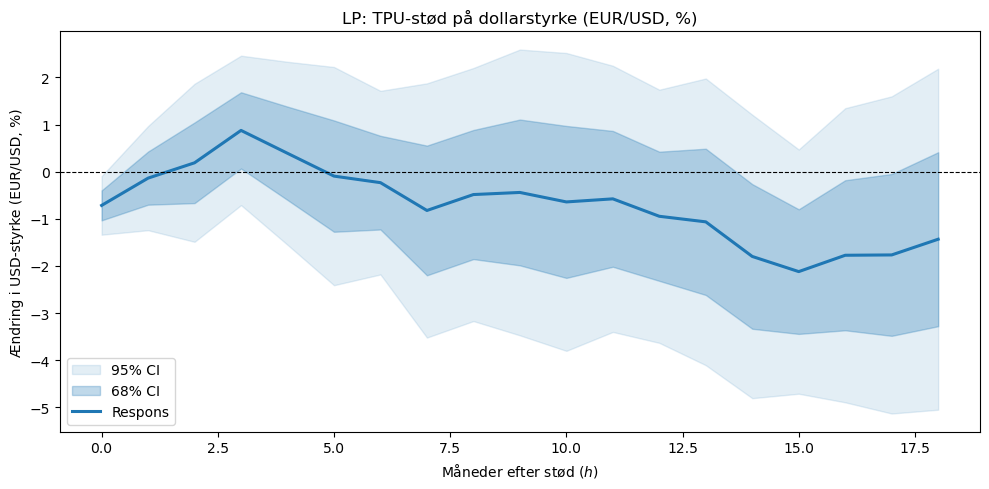

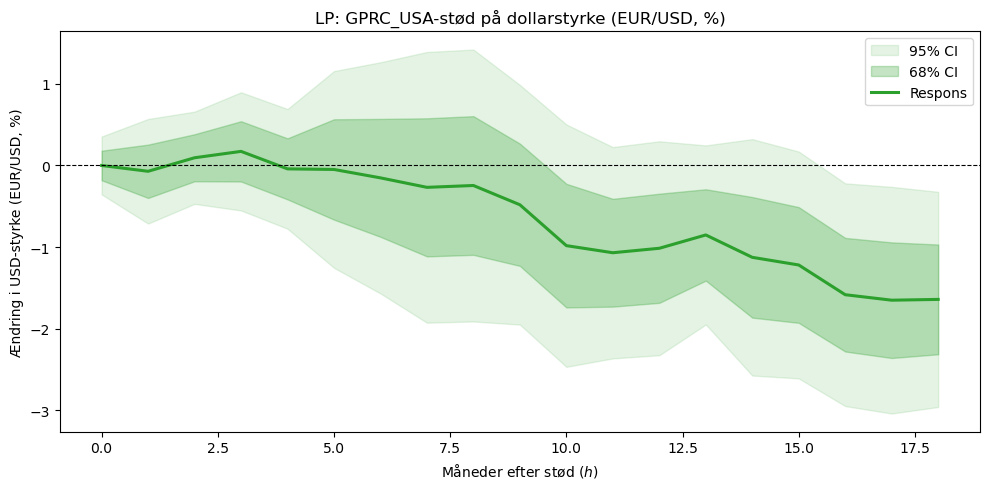

In [10]:
def lp_lagaug_y(master, outcome, indeks, H=18, LP_LAGS=1, NW_LAG=18, skala=1.0):
    """Lag-augmenteret LP med vilkårlig afhængig variabel.
    outcome: kolonnenavn (fx 'lnUSD' for dollarstyrke i log).
    indeks:  det log-standardiserede stød (fx 'lnTPU_z')."""
    d = master.copy().sort_values("month").reset_index(drop=True)
    d["y"] = d[outcome] * skala

    d[f"{indeks}_lag1"] = d[indeks].shift(1)
    kontroller = ["ip_growth", "inflation", "d_DGS10"]
    lag_termer = [f"{indeks}_lag1"]
    for var in kontroller:
        for L in range(1, LP_LAGS + 1):
            d[f"{var}_l{L}"] = d[var].shift(L)
            lag_termer.append(f"{var}_l{L}")
    kontrol_formel = " + ".join(lag_termer)

    res = []
    for h in range(H + 1):
        d[f"y_lead{h}"] = d["y"].shift(-h) - d["y"].shift(1)
        sub = d.dropna(subset=[f"y_lead{h}", indeks] + lag_termer)
        m = smf.ols(f"y_lead{h} ~ {indeks} + {kontrol_formel}",
                    data=sub).fit(cov_type="HAC", cov_kwds={"maxlags": NW_LAG})
        res.append({"h": h, "coef": m.params[indeks],
                     "se": m.bse[indeks], "n": int(m.nobs)})

    lp = pd.DataFrame(res)
    lp["ci68_low"], lp["ci68_high"] = lp["coef"]-lp["se"],      lp["coef"]+lp["se"]
    lp["ci95_low"], lp["ci95_high"] = lp["coef"]-1.96*lp["se"], lp["coef"]+1.96*lp["se"]
    lp["t"] = lp["coef"]/lp["se"]
    lp["p"] = 2*(1 - stats.norm.cdf(lp["t"].abs()))
    return lp

master["lnUSD"] = -np.log(master["EURUSD"])

lp_usd_tpu     = lp_lagaug_y(master, "lnUSD", "lnTPU_z",      LP_LAGS=1, skala=100)
lp_usd_gpr_usa = lp_lagaug_y(master, "lnUSD", "lnGPRC_USA_z", LP_LAGS=1, skala=100)

for navn, lp in [("USD ~ TPU", lp_usd_tpu), ("USD ~ GPR_USA", lp_usd_gpr_usa)]:
    print(f"\n=== {navn} ===")
    print(lp[["h","coef","se","t","p"]].round(3).to_string(index=False))

plot_lp(lp_usd_tpu,     "LP: TPU-stød på dollarstyrke (EUR/USD, %)", "tab:blue",
        ylabel="Ændring i USD-styrke (EUR/USD, %)")
plot_lp(lp_usd_gpr_usa, "LP: GPRC_USA-stød på dollarstyrke (EUR/USD, %)", "tab:green",
        ylabel="Ændring i USD-styrke (EUR/USD, %)")

In [11]:
def joint_signifikanstest_horisont(master, outcome, indeks, h_min, h_max, LP_LAGS=1, NW_LAG=18, skala=1.0):
    d = master.copy().sort_values("month").reset_index(drop=True)
    d["y"] = d[outcome] * skala

    kontroller = ["ip_growth", "inflation", "d_DGS10"]
    lag_termer = []
    for var in kontroller:
        for L in range(1, LP_LAGS + 1):
            d[f"{var}_l{L}"] = d[var].shift(L)
            lag_termer.append(f"{var}_l{L}")
    kontrol_formel = " + ".join(lag_termer)

    z_sub = d.dropna(subset=[indeks] + lag_termer).copy()
    m_z = smf.ols(f"{indeks} ~ {kontrol_formel}", data=z_sub).fit()
    d.loc[z_sub.index, "r_z"] = m_z.resid

    paneler = []
    for h in range(h_min, h_max + 1):
        d[f"y_lead{h}"] = d["y"].shift(-h) - d["y"].shift(1)
        sub = d.dropna(subset=[f"y_lead{h}"] + lag_termer).copy()
        m_y = smf.ols(f"y_lead{h} ~ {kontrol_formel}", data=sub).fit()
        sub["r_y"] = m_y.resid
        sub["hor"] = h
        paneler.append(sub[["month", "hor", "r_y", "r_z"]])

    panel = pd.concat(paneler, ignore_index=True).dropna(subset=["r_y", "r_z"])
    for h in range(h_min, h_max + 1):
        panel[f"r_z_{h}"] = panel["r_z"] * (panel["hor"] == h)

    z_kol = [f"r_z_{h}" for h in range(h_min, h_max + 1)]
    formel = "r_y ~ " + " + ".join(z_kol) + " + C(hor)"
    m = smf.ols(formel, data=panel).fit(cov_type="cluster", cov_kwds={"groups": panel["month"]})

    hyp = " = ".join(z_kol) + " = 0"
    joint = m.f_test(hyp)
    return m, joint

_, joint_gpr_long = joint_signifikanstest_horisont(master, "lnUSD", "lnGPRC_USA_z", 12, 18)
print(f"Joint test (GPR_USA, h=12-18): F={joint_gpr_long.fvalue:.3f}, p={joint_gpr_long.pvalue:.4f}")

_, joint_tpu_long = joint_signifikanstest_horisont(master, "lnUSD", "lnTPU_z", 12, 18)
print(f"Joint test (TPU, h=12-18): F={joint_tpu_long.fvalue:.3f}, p={joint_tpu_long.pvalue:.4f}")

Joint test (GPR_USA, h=12-18): F=2.708, p=0.0120
Joint test (TPU, h=12-18): F=2.136, p=0.0446
